# BPIC 2017: Exploratory Data Analysis

Conducted to verify that the dataset matches the assumptions made in the Exposé before any pipeline or model work begins. Findings are used in thesis Section 3.2 and serve as the basis of information for the design decisions in the preprocessing and encoding steps.

We use **BPIC 2017 v1**, the main event log without the separate offer file. Offer events are embedded in the main log under `O_*` activity names.

> **Pitfall:** Some attributes that feel like they are on the case-level (e.g. `LoanGoal`) are stored at the event level in the XES schema.

## 1: Load the XES Event Log

`pm4py` parses the XES file into an event log object, which is then flattened into a Pandas DataFrame where each row is one event. Timestamps are cast to `datetime64[ns, UTC]`.

Expected: 31,509 cases, 1,202,267 events, date range 2016-01-01 until 2017-02-01.

In [26]:
import warnings
from pm4py.objects.log.importer.xes.variants import iterparse
from pm4py.util import constants
import pm4py
import pandas as pd

# Disable pm4py warnings
constants.SHOW_PROGRESS_BAR = False
warnings.filterwarnings(
    "ignore",
    message="ISO8601 strings are not fully supported with strpfromiso*",
    category=UserWarning,
    module="pm4py.util.dt_parsing.parser",
)

# Load the BPIC 2017 + Convert
log = iterparse.apply("BPI Challenge 2017/BPI Challenge 2017.xes")
df = pm4py.convert_to_dataframe(log)
df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], utc=True)

# Save Cases and Events
n_cases = df["case:concept:name"].nunique()
n_events = len(df)
date_min = df["time:timestamp"].min()
date_max = df["time:timestamp"].max()

# Print statistic
print(f"Cases:     {n_cases:,}")
print(f"Events:    {n_events:,}")
print(f"Date range: {date_min.date()} : {date_max.date()}")
print(f"\nColumns:\n{df.columns.tolist()}")

Cases:     31,509
Events:    1,202,267
Date range: 2016-01-01 : 2017-02-01

Columns:
['Action', 'org:resource', 'concept:name', 'EventOrigin', 'EventID', 'lifecycle:transition', 'time:timestamp', 'case:LoanGoal', 'case:ApplicationType', 'case:concept:name', 'case:RequestedAmount', 'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost', 'Selected', 'CreditScore', 'OfferedAmount', 'OfferID']


## 2: Attribute Presence

Two types of input features are used in the model:

**Case attributes**: constant within a trace, attached to every event:
`case:RequestedAmount`, `case:LoanGoal`, `case:ApplicationType`

**Offer attributes**: event-level, only populated on `O_*` offer events:
`CreditScore`, `MonthlyCost`, `OfferedAmount`, `NumberOfTerms`

Offer columns are null for all non-offer events. The encoding step handles this via an `OfferPresent` flag and forward-fill. Once an offer event occurs, its values carry forward through the rest of the prefix. This preserves temporal correctness because the model is not able to see offer data before it exists in the process.

In [27]:
CASE_ATTRS  = ["case:RequestedAmount", "case:LoanGoal", "case:ApplicationType"]
OFFER_ATTRS = ["CreditScore", "MonthlyCost", "OfferedAmount", "NumberOfTerms"]

# Look for Null values and count them
print("\nNULL COUNTS")
print("-" * 70)
for col in CASE_ATTRS + OFFER_ATTRS:
    n_null = df[col].isna().sum()
    pct    = 100 * n_null / len(df)
    print(f"  {col:<35} {n_null:>8,}  ({pct:5.1f}%)")

# Inspect case attribute distributions (one row per case)
print("\nCASE ATTRIBUTES: Value Distributions")
print("-" * 70)
cases = df.drop_duplicates("case:concept:name")
for col in CASE_ATTRS:
    series = cases[col]
    print(f"\n{col}  (n={series.notna().sum():,})")
    if series.dtype in ["float64", "int64"]: print(series.describe().to_string())
    else: print(series.value_counts().to_string())

# Inspect offer attribute distributions (event-level, non-null only)
print("\nOFFER ATTRIBUTES: Value Distributions (non-null events)")
print("-" * 70)
for col in OFFER_ATTRS:
    series = df[col].dropna()
    print(f"\n{col}  (non-null events: {len(series):,})")
    if series.dtype in ["float64", "int64"]: print(series.describe().to_string())
    else: print(series.value_counts().to_string())


NULL COUNTS
----------------------------------------------------------------------
  case:RequestedAmount                       0  (  0.0%)
  case:LoanGoal                              0  (  0.0%)
  case:ApplicationType                       0  (  0.0%)
  CreditScore                         1,159,272  ( 96.4%)
  MonthlyCost                         1,159,272  ( 96.4%)
  OfferedAmount                       1,159,272  ( 96.4%)
  NumberOfTerms                       1,159,272  ( 96.4%)

CASE ATTRIBUTES: Value Distributions
----------------------------------------------------------------------

case:RequestedAmount  (n=31,509)
count     31509.000000
mean      16233.743989
std       15422.246299
min           0.000000
25%        6000.000000
50%       12500.000000
75%       21000.000000
max      450000.000000

case:LoanGoal  (n=31,509)
case:LoanGoal
Car                       9328
Home improvement          7669
Existing loan takeover    5601
Other, see explanation    2985
Unknown              

#### RequestedAmount Consistency

`RequestedAmount` is used as a partitioning attribute on the case level. The non-IID routing assumes that the value is stable within a case. The check below verifies this invariant before zero-amount cases are routed separately.


In [28]:
# Count distinct RequestedAmount values within each case
amount_nunique = df.groupby("case:concept:name")["case:RequestedAmount"].nunique(dropna=False)
changed_cases = amount_nunique[amount_nunique > 1]
n_cases = df["case:concept:name"].nunique()

# Print a summary, depending on the findings
print(f"Cases with changing RequestedAmount: {len(changed_cases):,} / {n_cases:,} ({len(changed_cases) / n_cases:.4%})")
if changed_cases.empty:
    print("RequestedAmount is stable within every case.")
else:
    changed_ids = changed_cases.index[:10]
    changed_view = (
        df.loc[df["case:concept:name"].isin(changed_ids), ["case:concept:name", "time:timestamp", "case:RequestedAmount"]]
        .drop_duplicates()
        .sort_values(["case:concept:name", "time:timestamp"])
    )
    print("Sample cases with changing RequestedAmount:")
    print(changed_view.to_string(index=False))


Cases with changing RequestedAmount: 0 / 31,509 (0.0000%)
RequestedAmount is stable within every case.


## 3: Outcome Ambiguity

A case can contain more than one decision event if it is reopened or receives later administrative handling. The pre-processing resolves this by using the **last** recorded decision event per case.

The outcome head has three target classes: `O_Accepted` maps to class 2, `A_Denied` maps to class 1 and `A_Cancelled` maps to class 0. Canceled cases remain in the dataset and are not masked, because they contain valid process information.

During training, multiclass cross-entropy loss is used for the outcome head. Class weighting is not fixed at the design stage. Given the long-tailed activity distribution, it remains a candidate regularization method to be evaluated empirically.


In [29]:
# Define the outcome classes and the mapping (labels -> class IDs)
DECISION_OUTCOMES = ["O_Accepted", "A_Denied", "A_Cancelled"]
OUTCOME_MAPPING = {"O_Accepted": 2, "A_Denied": 1, "A_Cancelled": 0}

# Select recognized decision events and keep the last one per case
ordered = df.sort_values(["case:concept:name", "time:timestamp"]).copy()
ordered["event_pos"] = ordered.groupby("case:concept:name").cumcount() + 1
outcome_events = ordered[ordered["concept:name"].isin(DECISION_OUTCOMES)].copy()
outcome_counts = outcome_events.groupby("case:concept:name")["concept:name"].agg(["count", "nunique"])
last_outcome = (
    outcome_events.sort_values(["case:concept:name", "time:timestamp", "event_pos"])
    .groupby("case:concept:name")
    .tail(1)
    .set_index("case:concept:name")
)
last_outcome["outcome_class"] = last_outcome["concept:name"].map(OUTCOME_MAPPING).astype(int)

# Count the number of outcomes per class, per case and the number of distinct outcomes
n_accepted = int((last_outcome["concept:name"] == "O_Accepted").sum())
n_denied = int((last_outcome["concept:name"] == "A_Denied").sum())
n_cancelled = int((last_outcome["concept:name"] == "A_Cancelled").sum())
n_multi = int((outcome_counts["count"] > 1).sum())
n_multi_distinct = int((outcome_counts["nunique"] > 1).sum())
n_no_outcome = n_cases - len(last_outcome)

print(f"Cases with >1 decision event:       {n_multi:,}")
print(f"Cases with >1 decision label:       {n_multi_distinct:,}")
print(f"Cases with O_Accepted -> class 2:   {n_accepted:,}")
print(f"Cases with A_Denied -> class 1:     {n_denied:,}")
print(f"Cases with A_Cancelled -> class 0:  {n_cancelled:,}")
print(f"Total with decision event:          {len(last_outcome):,}")
print(f"Cases without decision event:       {n_no_outcome:,}")

# Check cases without an outcome event for timestamp concentration near the log cutoff
no_outcome_ids = set(df["case:concept:name"].unique()) - set(last_outcome.index)
no_outcome_cases = df[df["case:concept:name"].isin(no_outcome_ids)]
print(no_outcome_cases.groupby("case:concept:name")["time:timestamp"].max().describe())

Cases with >1 decision event:       1
Cases with >1 decision label:       0
Cases with O_Accepted -> class 2:   17,228
Cases with A_Denied -> class 1:     3,752
Cases with A_Cancelled -> class 0:  10,431
Total with decision event:          31,411
Cases without decision event:       98
count                                     98
mean     2017-01-17 13:01:05.475193856+00:00
min         2017-01-02 08:55:26.535000+00:00
25%      2017-01-06 12:32:40.418249984+00:00
50%      2017-01-16 21:30:38.935000064+00:00
75%      2017-01-28 09:32:21.105499904+00:00
max         2017-02-01 14:11:03.499000+00:00
Name: time:timestamp, dtype: object


#### Offer Event Visibility by Terminal State

Cases end in one of three terminal states: `A_Pending`, `A_Denied` or `A_Cancelled`. This cell reports at which trace position each terminal state typically occurs and whether offer events are present in the case by that point. It also shows which specific offer activities appear per terminal state.

In [30]:
import numpy as np

# Define the terminal states and offer activities
APPLICATION_TERMINAL_ACTIVITIES = ["A_Pending", "A_Denied", "A_Cancelled"]
OFFER_ACTIVITIES = ["O_Created", "O_Sent (mail and online)", "O_Sent (online only)", "O_Returned", "O_Accepted", "O_Refused", "O_Cancelled"]

# Sort events chronologically and tag each with the absolute position, trace length and relative position
df_ordered = df.sort_values(["case:concept:name", "time:timestamp"]).copy()
df_ordered["event_pos"] = df_ordered.groupby("case:concept:name").cumcount() + 1
df_ordered["trace_len"] = df_ordered.groupby("case:concept:name")["concept:name"].transform("size")
df_ordered["rel_pos"]   = df_ordered["event_pos"] / df_ordered["trace_len"]

# Retrieve the final terminal event per case on the application level
last_outcome = (
    df_ordered[df_ordered["concept:name"].isin(APPLICATION_TERMINAL_ACTIVITIES)]
    .sort_values(["case:concept:name", "time:timestamp", "event_pos"])
    .groupby("case:concept:name")
    .tail(1)
    .set_index("case:concept:name")
)

# Report at which trace position each terminal state typically occurs
outcome_position_summary = (
    last_outcome.groupby("concept:name")
    .agg(
        n_cases = ("concept:name", "size"),
        mean_event_pos = ("event_pos", "mean"),
        mean_trace_len = ("trace_len", "mean"),
        mean_rel_pos = ("rel_pos", "mean"),
    )
)
print("\nPosition of application-level terminal events")
print("-" * 72)
print(outcome_position_summary.round(3))

# Flag whether each case contains at least one offer event
case_has_offer = (
    df_ordered
    .assign(has_offer=df_ordered["concept:name"].isin(OFFER_ACTIVITIES))
    .groupby("case:concept:name")["has_offer"].any()
)

# Offer presence per terminal state
offer_check = (
    last_outcome
    .assign(has_offer=last_outcome.index.map(case_has_offer))
    .groupby("concept:name")
    .agg(n_cases = ("concept:name", "size"), n_with_offer = ("has_offer", "sum"), share_with_offer = ("has_offer", "mean"))
)
print("\nOffer visibility by terminal state")
print("-" * 72)
print(offer_check.round(3))

# Specific offer activities per terminal state
offer_presence = (
    df_ordered[df_ordered["concept:name"].isin(OFFER_ACTIVITIES)]
    .merge(last_outcome["concept:name"].rename("final_outcome"), left_on="case:concept:name", right_index=True, how="inner")
    .groupby(["final_outcome", "concept:name"])
    .size()
    .unstack(fill_value=0)
)
print("\nOffer event counts by terminal state")
print("-" * 72)
print(offer_presence)


Position of application-level terminal events
------------------------------------------------------------------------
              n_cases  mean_event_pos  mean_trace_len  mean_rel_pos
concept:name                                                       
A_Cancelled     10431          23.996          26.244         0.908
A_Denied         3752          36.501          38.753         0.937
A_Pending       17228          43.889          45.227         0.969

Offer visibility by terminal state
------------------------------------------------------------------------
              n_cases  n_with_offer  share_with_offer
concept:name                                         
A_Cancelled     10431         10431               1.0
A_Denied         3752          3752               1.0
A_Pending       17228         17228               1.0

Offer event counts by terminal state
------------------------------------------------------------------------
concept:name   O_Accepted  O_Cancelled  O_Created 

#### Temporal Ordering of Offer and Application Outcomes

Outcome events on the offer level (`O_Accepted`, `O_Refused`, `O_Cancelled`) and terminal events on the application level are recorded as separate activities in the log. This cell checks whether offer outcomes precede or follow the final application terminal event. The ordering is relevant for the outcome label choice discussed below.

In [31]:
# Define offer terminal states that could be candidates for the outcome labels
OFFER_OUTCOME_ACTIVITIES = ["O_Accepted", "O_Refused", "O_Cancelled"]

# Rebuild df_ordered with event position only (trace_len and rel_pos not needed)
df_ordered = df.sort_values(["case:concept:name", "time:timestamp"]).copy()
df_ordered["event_pos"] = df_ordered.groupby("case:concept:name").cumcount() + 1

# Retrieve the final terminal event on the application level per case with its position and timestamp
last_outcome = (
    df_ordered[df_ordered["concept:name"].isin(APPLICATION_TERMINAL_ACTIVITIES)]
    .sort_values(["case:concept:name", "time:timestamp", "event_pos"])
    .groupby("case:concept:name")
    .tail(1)
    .rename(columns={"concept:name": "final_outcome", "time:timestamp": "outcome_time", "event_pos": "outcome_pos"})
    [["case:concept:name", "final_outcome", "outcome_time", "outcome_pos"]]
)

# Align each offer level outcome event with the application level terminal event of the same case
offer_outcomes = df_ordered[df_ordered["concept:name"].isin(OFFER_OUTCOME_ACTIVITIES)]
offer_timing = offer_outcomes.merge(last_outcome, on="case:concept:name", how="inner")

# Classify each offer outcome as before, same position or after the application terminal event
offer_timing["relative_to_outcome"] = np.select(
    [
        offer_timing["event_pos"] < offer_timing["outcome_pos"],
        offer_timing["event_pos"] == offer_timing["outcome_pos"],
        offer_timing["event_pos"] > offer_timing["outcome_pos"],
    ],
    ["before", "same", "after"],
    default="unknown",
)

# Summarize counts per application outcome, per offer event type and per relative position
summary = (offer_timing.groupby(["final_outcome", "concept:name", "relative_to_outcome"]).size().unstack(fill_value=0))
print("Offer outcome events relative to final application outcome")
print(summary)

Offer outcome events relative to final application outcome
relative_to_outcome         after  before
final_outcome concept:name               
A_Cancelled   O_Cancelled   13008     727
A_Denied      O_Cancelled       0     237
              O_Refused      4693       2
A_Pending     O_Accepted        0   17228
              O_Cancelled    5802    1118


#### Outcome label decision

The outcome head uses three decision classes. `O_Accepted` is the accepted offer class, `A_Denied` is the denial class on the bank side and `A_Cancelled` is the cancellation class.

`A_Accepted` remains rejected as a target because it marks an intermediate application state. `A_Pending` remains rejected because it follows `O_Accepted` deterministically and would weaken next-activity prediction. `O_Accepted` is retained as the accepted offer decision event because the BPMN 2.0 model places it directly before `A_Pending`.

![img](../_paper/Accepted-Pending.png)

**Decided mapping:**

- **Class 2:** `O_Accepted` (customer accepted an offer)
- **Class 1:** `A_Denied` (the bank denied the application)
- **Class 0:** `A_Cancelled` (the application was closed without acceptance)

`A_Cancelled` is kept as a valid target. It contains process information about dropped or non-converted applications and is therefore a valid prediction target.


#### Trace Cutting at the Decision Event

During preprocessing every trace will be cut after the final recognized decision event. The decision event itself remains in the trace. All later events are considered administrative for this prediction setup, so `RemainingTime` becomes time-to-decision and `[END]` follows the decision event. This reflects the model scope: Sequence, timing and outcome are predicted only up to the point where the final outcome is reached.


In [32]:
# Define the outcome labels
DECISION_OUTCOMES = ["O_Accepted", "A_Denied", "A_Cancelled"]

# Locate the final decision event per case
ordered = df.sort_values(["case:concept:name", "time:timestamp"]).copy()
ordered["event_pos"] = ordered.groupby("case:concept:name").cumcount()
ordered["activity_token"] = ordered["concept:name"].astype(str) + "+" + ordered["lifecycle:transition"].astype(str)
decision_events = ordered[ordered["concept:name"].isin(DECISION_OUTCOMES)].copy()
counts = decision_events.groupby("case:concept:name")["concept:name"].agg(["count", "nunique"])
last_decision = (
    decision_events.sort_values(["case:concept:name", "time:timestamp", "event_pos"])
    .groupby("case:concept:name")
    .tail(1)
    .rename(columns={"event_pos": "decision_pos", "time:timestamp": "decision_time"})
    .set_index("case:concept:name")
)

# Cut after the final decision event and validate the resulting NextActivity target
ordered["decision_pos"] = ordered["case:concept:name"].map(last_decision["decision_pos"])
has_decision = ordered["decision_pos"].notna()
keep = ~has_decision | (ordered["event_pos"] <= ordered["decision_pos"])
cut_events = ordered.loc[keep].copy()
cut_events["NextActivity"] = cut_events.groupby("case:concept:name")["activity_token"].shift(-1).fillna("[END]")

# Count activities removed by the cutoff filter and verify no post-decision events remain
removed = int((~keep).sum())
base = int(has_decision.sum())
# Should be 0: any surviving event beyond the decision point is a pipeline error
share_removed = removed / base if base else 0.0
post_cut_remaining = int((cut_events["event_pos"] > cut_events["decision_pos"]).sum())
# Should be True: every truncated trace must close with [END]
end_token_ok = bool(cut_events.groupby("case:concept:name")["NextActivity"].last().eq("[END]").all())

print(f"Cases with a decision event:             {len(last_decision):,}")
print(f"Cases with >1 decision event:            {int((counts['count'] > 1).sum()):,}")
print(f"Cases with >1 distinct decision label:   {int((counts['nunique'] > 1).sum()):,}")
print(f"Events removed after decision:           {removed:,} ({share_removed:.2%} of events in decision cases)")
print(f"Events after decision in cut trace:      {post_cut_remaining:,}")
print(f"Last NextActivity is [END] for all cases: {end_token_ok}")


Cases with a decision event:             31,411
Cases with >1 decision event:            1
Cases with >1 distinct decision label:   0
Events removed after decision:           72,172 (6.02% of events in decision cases)
Events after decision in cut trace:      0
Last NextActivity is [END] for all cases: True


## 4: Activity Analysis

Activities follow a prefix convention: `A_` for application events, `W_` for manual work items, `O_` for offer events. BPIC 2017 records seven distinct `lifecycle:transition` values, so the next-activity target is built from a lifecycle-aware activity token, formed as `concept:name + "+" + lifecycle:transition`. The raw `concept:name` is kept unchanged for outcome labels and descriptive statistics.

The vocabulary is built over these activity tokens on the union of the bank training splits only (no leakage), with three reserved indices `[PAD] = 0`, `[UNK] = 1` and `[END] = 2`. Vocabularies are built later in the shared prefix-encoding step from the union of the bank training splits only. Validation and test activities are not used when fitting vocabulary indices. A reserved `[END]` token marks the end of each cut trace, while unseen validation or test tokens map to `[UNK]` during encoding.

Unique activities: 26

All activities:
concept:name
W_Validate application        209496
W_Call after offers           191092
W_Call incomplete files       168529
W_Complete application        148900
W_Handle leads                 47264
O_Create Offer                 42995
O_Created                      42995
O_Sent (mail and online)       39707
A_Validating                   38816
A_Create Application           31509
A_Concept                      31509
A_Accepted                     31509
A_Complete                     31362
O_Returned                     23305
A_Incomplete                   23055
O_Cancelled                    20898
A_Submitted                    20423
O_Accepted                     17228
A_Pending                      17228
A_Cancelled                    10431
O_Refused                       4695
A_Denied                        3753
W_Assess potential fraud        3282
O_Sent (online only)            2026
W_Shortened completion           238
W_Personal Loan collect

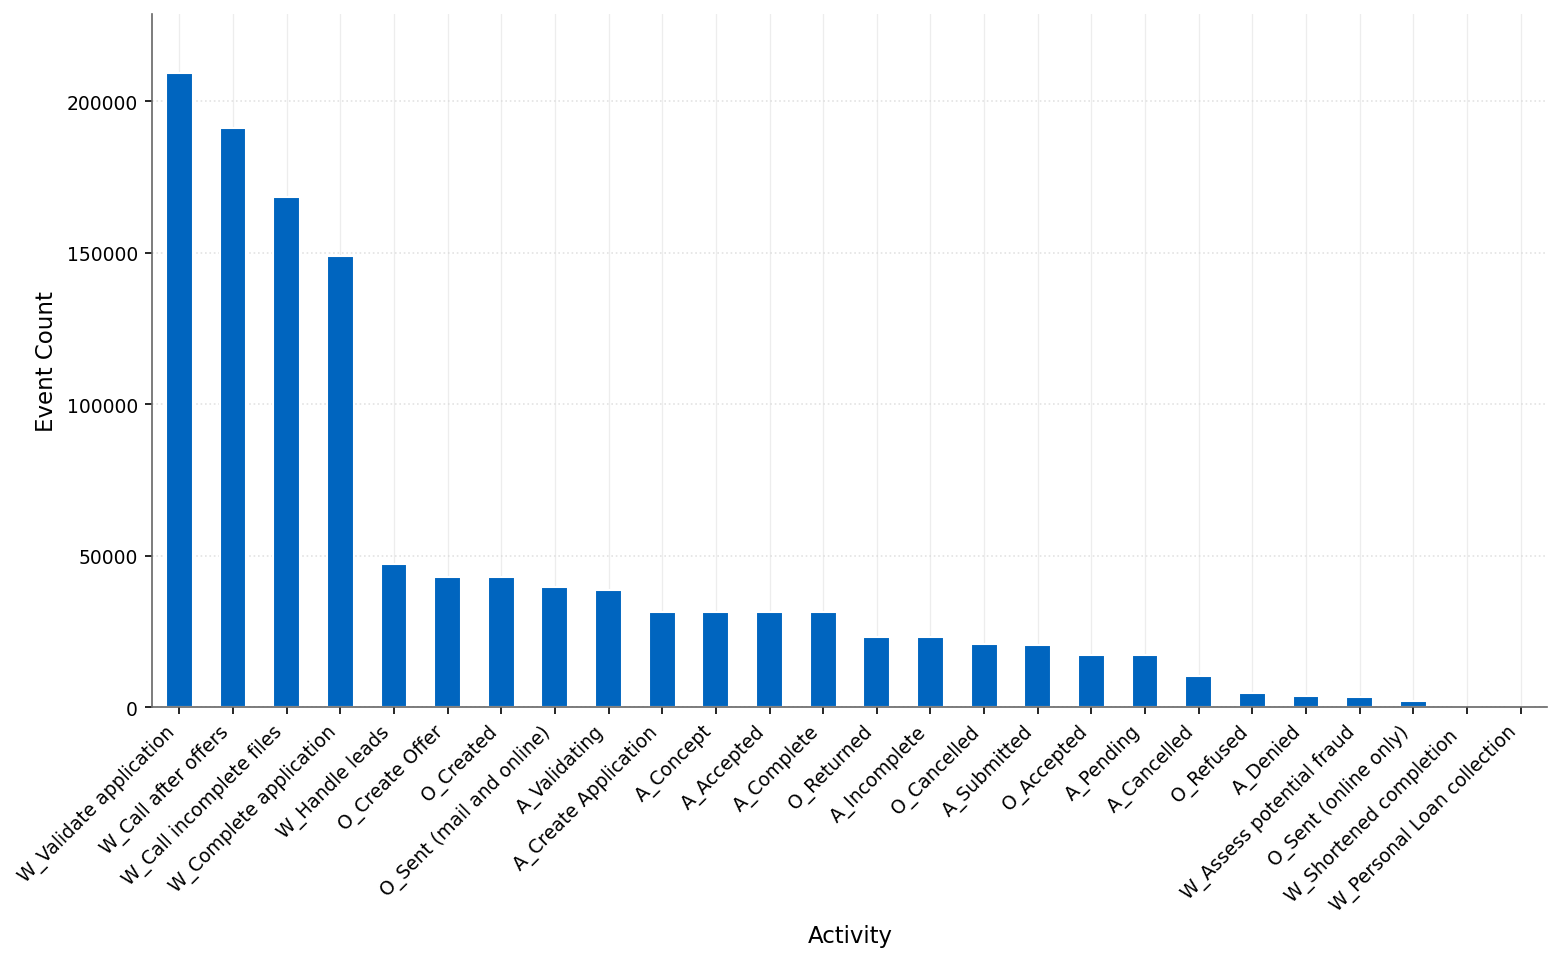

Saved: plots/A_01_activity_freq.png


In [33]:
import matplotlib.pyplot as plt
import os

# Figure colors (convention for grid, spine and legend)
GRID_COLOR = "#d9d9d9"
SPINE_COLOR = "#666666"
LEGEND_EDGE = "#bfbfbf"

# HELPER: Figure grid and spine styling
def _style_graph_axes(ax_temp, x_margin=0.04):
    ax_temp.grid(False)
    ax_temp.grid(axis="x", linestyle="-", linewidth=0.6, color=GRID_COLOR, alpha=0.45)
    ax_temp.grid(axis="y", linestyle=":", linewidth=0.8, color=GRID_COLOR, alpha=0.75)
    ax_temp.set_axisbelow(True)
    ax_temp.margins(x=x_margin)
    ax_temp.spines["top"].set_visible(False)
    ax_temp.spines["right"].set_visible(False)
    for side in ("left", "bottom"):
        ax_temp.spines[side].set_color(SPINE_COLOR)
        ax_temp.spines[side].set_linewidth(0.8)

# HELPER: Figure legend styling
def _style_reference_legend(legend):
    frame = legend.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor(LEGEND_EDGE)
    frame.set_alpha(0.78)
    frame.set_linewidth(0.8)

# HELPER: Pad the top of the figure by a fraction of the figure height
def _pad_top(ax_tamp, fraction=0.12):
    low, high = ax_tamp.get_ylim()
    ax_tamp.set_ylim(low, high + (high - low) * fraction)

# Set global figure parameters
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Create the plots directory if it doesn't exist and count activities
os.makedirs("plots", exist_ok=True)
activity_counts = df["concept:name"].value_counts()
print(f"Unique activities: {len(activity_counts)}")
print(f"\nAll activities:\n{activity_counts.to_string()}")

# Create the activity frequency plot
fig, ax = plt.subplots(figsize=(12, 6))
activity_counts.plot(kind="bar", ax=ax, color="#0065BF", edgecolor="white")
ax.set_xlabel("Activity")
ax.set_ylabel("Event Count")
ax.tick_params(axis="x", labelrotation=45, labelsize=9)

# Right-align rotated labels so they hang from the tick, not center on it
for label in ax.get_xticklabels(): label.set_horizontalalignment("right")

# Apply axis styling and add headroom above the tallest bar
_style_graph_axes(ax)
_pad_top(ax, fraction=0.04)

# Tighten spacing and save the figure
plt.savefig("plots/A_01_activity_freq.png", dpi=300, bbox_inches="tight", pad_inches=0.12)
plt.show()
print("Saved: plots/A_01_activity_freq.png")

## 5: Case Duration

Case duration describes the raw process length. The supervised **RemainingTime** target is computed after trace cutting, so it measures `timestamp(decision event) - timestamp(current event)`.

A_02 stores this target in raw seconds. Prefix encoding owns the optional `log1p` transformed target variant, because the transform is an experiment choice rather than a preprocessing label definition.


Mean duration:    21.90 days
Median duration:  19.09 days
95th percentile:  42.52 days


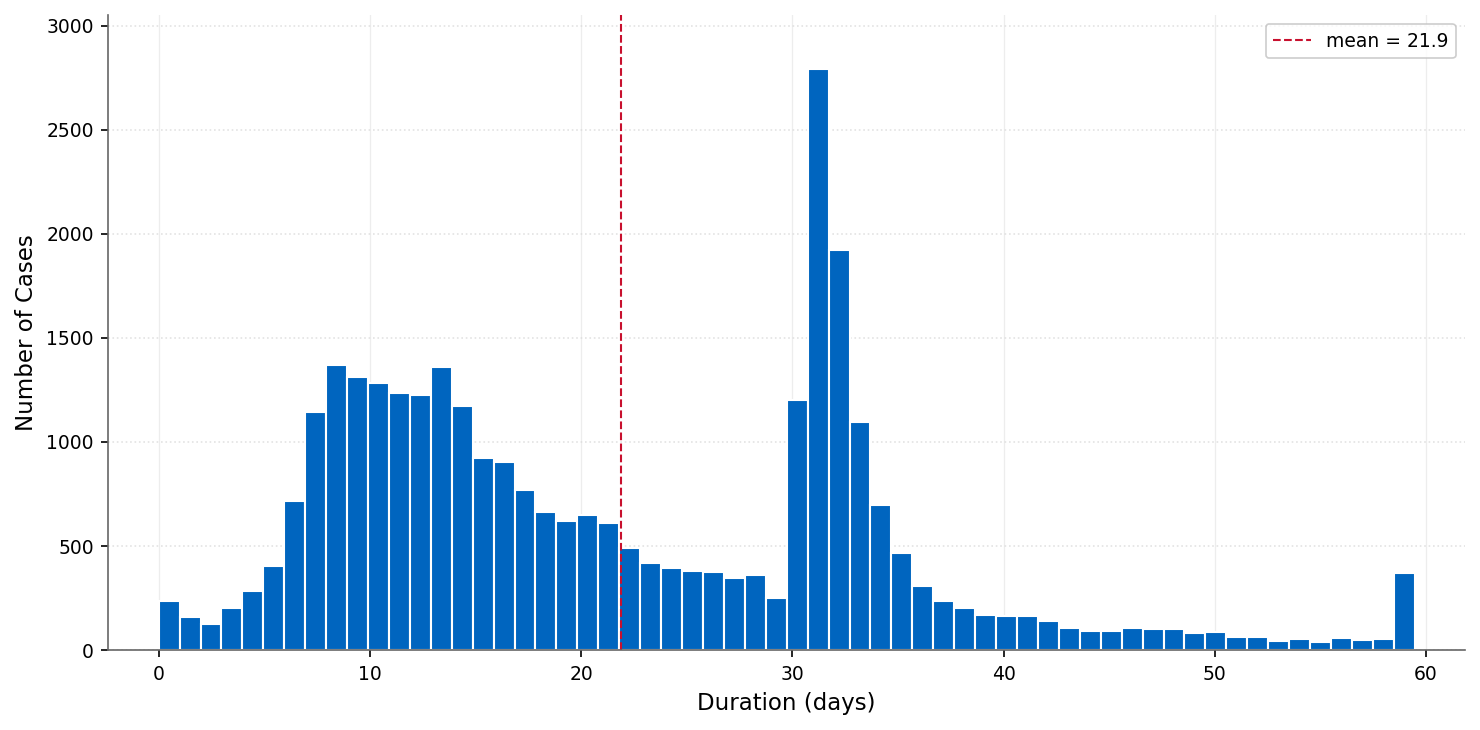

Saved: plots/A_01_case_duration.png


In [34]:
# Get case durations
case_times = df.groupby("case:concept:name")["time:timestamp"].agg(["min", "max"])
case_times["duration_days"] = (case_times["max"] - case_times["min"]).dt.total_seconds() / 86400
print(f"Mean duration:    {case_times['duration_days'].mean():.2f} days")
print(f"Median duration:  {case_times['duration_days'].median():.2f} days")
print(f"95th percentile:  {case_times['duration_days'].quantile(0.95):.2f} days")

# Plot case durations as histogram (0065BF: TUM blue)
fig, ax = plt.subplots(figsize=(10, 5))
case_times["duration_days"].clip(upper=case_times["duration_days"].quantile(0.99)).hist(
    bins=60, ax=ax, color="#0065BF", edgecolor="white"
)
ax.set_xlabel("Duration (days)")
ax.set_ylabel("Number of Cases")

# Mean reference line (C8102E: Highlight red)
_mean_val = case_times["duration_days"].mean()
ax.axvline(_mean_val, color="#C8102E", linewidth=1, linestyle="--", label=f"mean = {_mean_val:,.1f}")
_legend = ax.legend(loc="upper right")
_style_reference_legend(_legend)

# Apply axis styling and add headroom above the tallest bar
_style_graph_axes(ax)
_pad_top(ax, fraction=0.04)

# Tighten spacing and save the figure
fig.tight_layout(pad=1.2)
plt.savefig("plots/A_01_case_duration.png", dpi=300)
plt.show()
print("Saved: plots/A_01_case_duration.png")

## 6: Prefix Length Distribution

Each case of length *n* generates *n* training samples before any prefix cap is applied. The distribution of events per case determines the total dataset size and padding overhead.

`MAX_PREFIX_LENGTH_FOR_ENCODING` is a preprocessing parameter derived from the data. It is not a documented BPIC 2017 benchmark convention. It is set to the 98th percentile of case length before outcome-event cutting, which yields `MAX_PREFIX_LENGTH_FOR_ENCODING = 83`. The distribution below justifies the value and quantifies how many decision events lie after the cutoff. For those affected cases, the diagnostic reports how many events lie between the cap and the final decision event, including the decision event itself. It is important that the trace is not physically truncated to preserve the outcome label for cases whose decision event lies beyond the cap.


Mean prefix length:   38.2
Max prefix length:    180
98th percentile:      83.0
Decision events beyond cap: 489 (1.56% of decision cases)
Longest decision length beyond cap: 176 events
Max cap-to-decision gap: 93 events
Mean cap-to-decision gap: 14.9 events


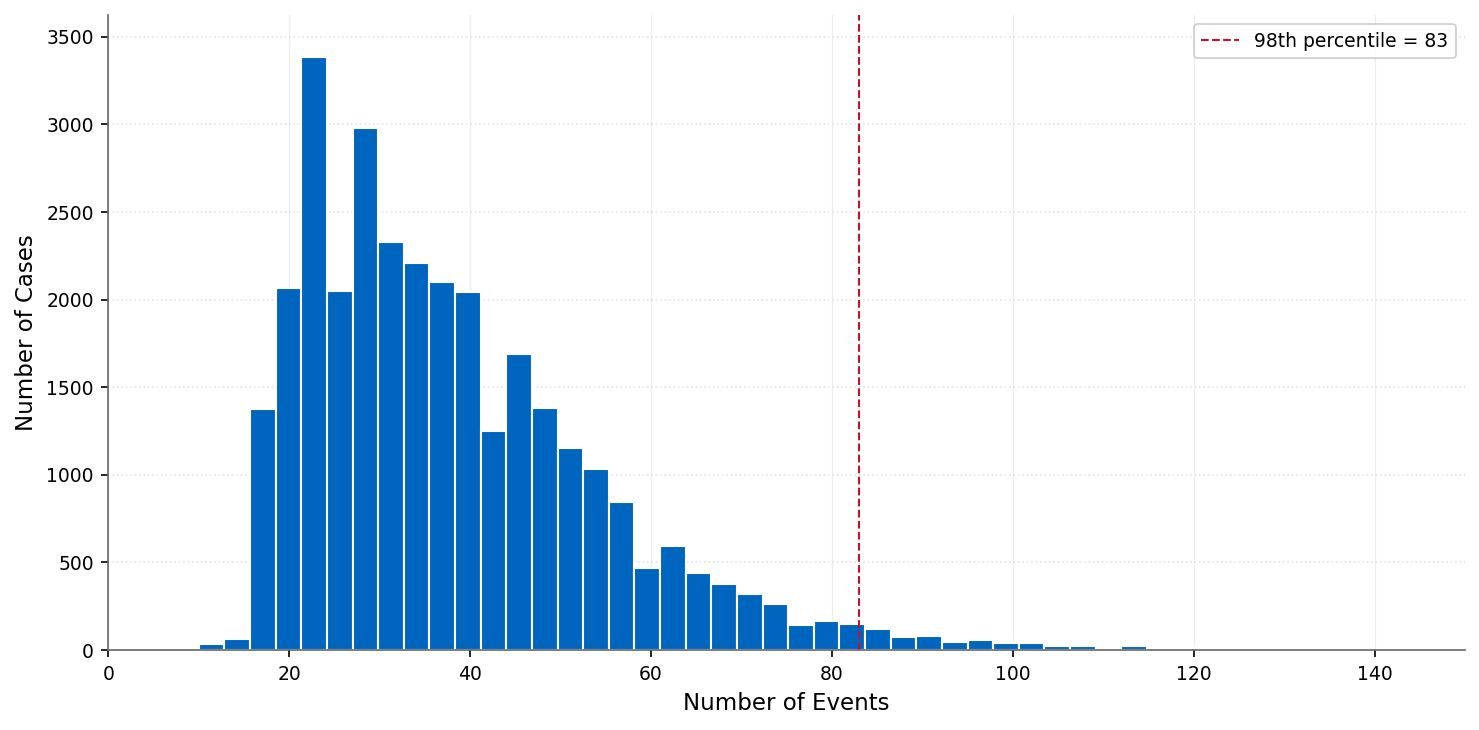

Saved: plots/A_01_prefix_length.png


In [35]:
# Retrieve the prefix length before outcome-event cutting
prefix_lengths = df.groupby("case:concept:name").size()
p98 = prefix_lengths.quantile(0.98)
cap = int(p98)
decision_length = last_decision["decision_pos"] + 1
decision_over_cap = decision_length[decision_length > cap] - cap
decision_after_cap = int(decision_over_cap.size)
decision_after_cap_share = decision_after_cap / len(last_decision)
max_gap_to_decision = int(decision_over_cap.max()) if decision_after_cap else 0
mean_gap_to_decision = float(decision_over_cap.mean()) if decision_after_cap else 0.0
longest_decision_length = int(decision_length[decision_length > cap].max()) if decision_after_cap else cap

# Print a summary
print(f"Mean prefix length:   {prefix_lengths.mean():.1f}")
print(f"Max prefix length:    {prefix_lengths.max()}")
print(f"98th percentile:      {p98:.1f}")
print(f"Decision events beyond cap: {decision_after_cap:,} ({decision_after_cap_share:.2%} of decision cases)")
print(f"Longest decision length beyond cap: {longest_decision_length:,} events")
print(f"Max cap-to-decision gap: {max_gap_to_decision:,} events")
print(f"Mean cap-to-decision gap: {mean_gap_to_decision:.1f} events")

# Plot the prefix length
fig, ax = plt.subplots(figsize=(10, 5))
prefix_lengths.clip(upper=prefix_lengths.quantile(1)).hist(bins=60, ax=ax, color="#0065BF", edgecolor="white")

# Mark the 98th percentile cap for later prefix encoding
ax.axvline(cap, color="#C8102E", linewidth=1, linestyle="--", label=f"98th percentile = {cap:.0f}")
_legend = ax.legend(loc="upper right")
_style_reference_legend(_legend)

# Label axes, constrain the x-range, apply styling
ax.set_xlabel("Number of Events")
ax.set_ylabel("Number of Cases")
ax.set_xlim(0, 150)
_style_graph_axes(ax)
_pad_top(ax, fraction=0.02)
fig.tight_layout(pad=1.2)

# Save the figure
plt.savefig("plots/A_01_prefix_length.png", dpi=300)
plt.show()
print("Saved: plots/A_01_prefix_length.png")


## 7: RequestedAmount Distribution

`RequestedAmount` is the primary attribute for **non-IID client partitioning**. Different banks naturally serve different market segments: Large loans, mid-range and small consumer credit.


RequestedAmount distribution (case-level):
  Min:             0
  Max:       450,000
  Mean:       16,234
  p10:         5,000
  p25:         6,000
  p50:        12,500
  p75:        21,000
  p90:        35,000


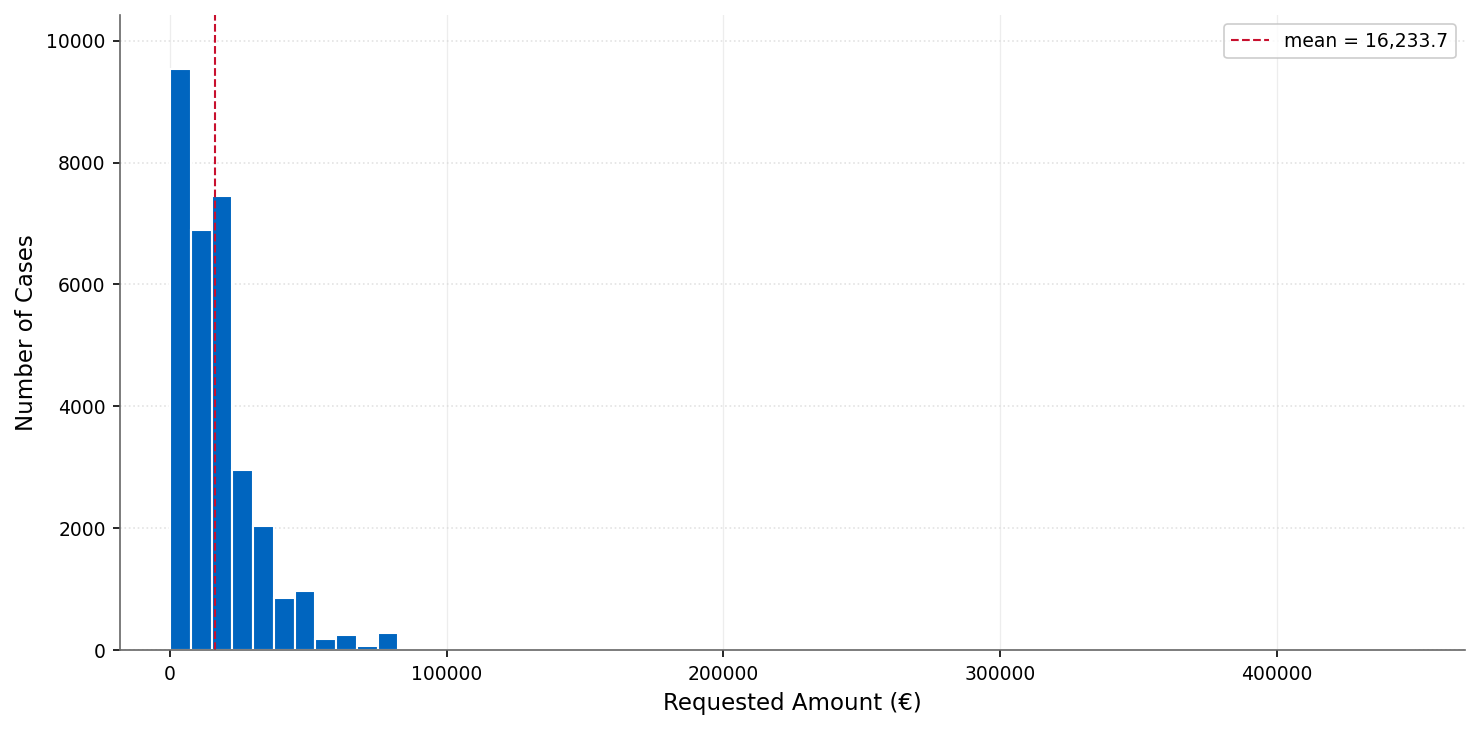

Saved: plots/A_01_requested_amount.png


In [36]:
# Get a unique requested amount for each case
amounts = df.drop_duplicates("case:concept:name")["case:RequestedAmount"]
print("RequestedAmount distribution (case-level):")
print(f"  Min:  {amounts.min():>12,.0f}")
print(f"  Max:  {amounts.max():>12,.0f}")
print(f"  Mean: {amounts.mean():>12,.0f}")

# Report distribution quantiles for the requested amount
for p in [10, 25, 50, 75, 90]: print(f"  p{p:<2}:  {amounts.quantile(p/100):>12,.0f}")

# Plot the requested amount for each case
fig, ax = plt.subplots(figsize=(10, 5))
amounts.hist(bins=60, ax=ax, color="#0065BF", edgecolor="white")
ax.set_xlabel("Requested Amount (€)")
ax.set_ylabel("Number of Cases")

# Add the mean reference line and legend
_mean_val = amounts.mean()
ax.axvline(_mean_val, color="#C8102E", linewidth=1, linestyle="--", label=f"mean = {_mean_val:,.1f}")
_legend = ax.legend(loc="upper right")
_style_reference_legend(_legend)

# Apply axis styling and add headroom above the tallest bar
_style_graph_axes(ax)
_pad_top(ax, fraction=0.04)

# Tighten spacing and save the figure
fig.tight_layout(pad=1.2)
plt.savefig("plots/A_01_requested_amount.png", dpi=300)
plt.show()
print("Saved: plots/A_01_requested_amount.png")

## 8: Approval Rate by RequestedAmount Quintile

`RequestedAmount` is used as the primary partitioning attribute. Cases are grouped into five amount quintiles to test whether approval shares differ across requested loan sizes.

Truncation cases are dropped, canceled cases are kept as class 0 and `pd.qcut` runs on the non-zero subset (cases with `RequestedAmount = 0` are covered in section 9). The approval share is computed as accepted cases divided by all decision-labeled cases in the bin.


 amount_tier  amount_min  amount_max  total  approved  approval_rate
 Q1 (lowest)       600.0      6500.0   5704      2430       0.426017
          Q2      6552.0     10250.0   5642      2921       0.517724
          Q3     10300.0     16000.0   5914      3472       0.587082
          Q4     16025.0     25000.0   5704      3344       0.586255
Q5 (highest)     25001.0    450000.0   5370      3053       0.568529

Overall approval share (non-zero): 0.537


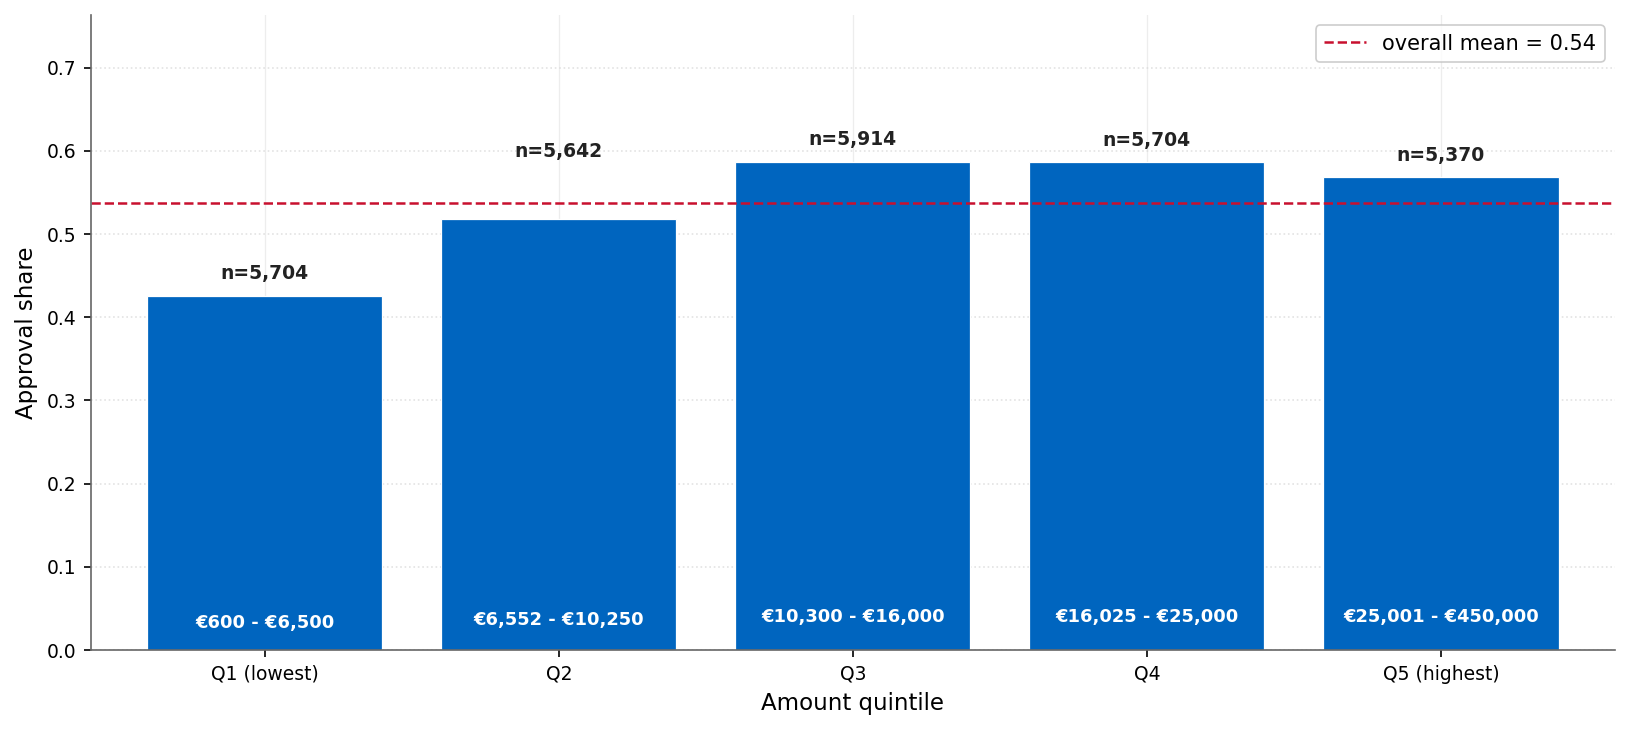

Saved: plots/A_01_approval_by_amount_tier.png


In [37]:
# Define the event outcomes
APPROVED, DENIED, CANCELLED = "O_Accepted", "A_Denied", "A_Cancelled"
OUTCOME_EVENTS = [APPROVED, DENIED, CANCELLED]

# Build the final multiclass outcome source per case from recognized decision events
last_outcome = (
    df[df["concept:name"].isin(OUTCOME_EVENTS)]
    .sort_values("time:timestamp")
    .groupby("case:concept:name")["concept:name"].last()
    .reset_index().rename(columns={"concept:name": "outcome"})
)

# Keep one row per case, drop truncation cases and retain canceled cases
case_amount = (
    df.drop_duplicates("case:concept:name")[["case:concept:name", "case:RequestedAmount"]]
    .rename(columns={"case:RequestedAmount": "requested_amount"})
)
meta = case_amount.merge(last_outcome, on="case:concept:name", how="inner")
meta["approved"] = (meta["outcome"] == APPROVED).astype(int)

# Split non-zero amounts into quintiles with pd.qcut()
nonzero = meta.loc[meta["requested_amount"] > 0].copy()
nonzero["amount_quintile"] = pd.qcut(nonzero["requested_amount"], q=5, labels=False, duplicates="drop").astype(int)

# Apply Q1 (lowest) and Qn (highest) boundary labels for the bar chart
n_tiers = nonzero["amount_quintile"].nunique()
tier_labels = {i: f"Q{i + 1}" for i in range(n_tiers)}
tier_labels[0] = "Q1 (lowest)"
tier_labels[n_tiers - 1] = f"Q{n_tiers} (highest)"
nonzero["amount_tier"] = nonzero["amount_quintile"].map(tier_labels)

# Calculate approval rate per amount quintile, canceled cases count in the denominator but not as approvals
tier_stats = (
    nonzero.groupby(["amount_quintile", "amount_tier"], observed=True)
    .agg(
        total = ("approved", "size"),
        approved = ("approved", "sum"),
        amount_min = ("requested_amount", "min"),
        amount_max = ("requested_amount", "max"),
    )
    .assign(approval_rate=lambda d: d["approved"] / d["total"])
    .reset_index()
    .sort_values("amount_quintile")
)
overall_mean = float(nonzero["approved"].mean())

# Print the quintile summary for the thesis
print(tier_stats[["amount_tier", "amount_min", "amount_max", "total", "approved", "approval_rate"]].to_string(index=False))
print(f"\nOverall approval share (non-zero): {overall_mean:.3f}")

# Plot approval share by requested amount quintile, with the amount range placed inside each bar
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(tier_stats["amount_tier"], tier_stats["approval_rate"], color="#0065BF", edgecolor="white", linewidth=0.6)

# Place the amount range inside the bar and the case count above it
for bar, row in zip(bars, tier_stats.itertuples(index=False)):
    x = bar.get_x() + bar.get_width() / 2
    ax.text(
        x, bar.get_height() * 0.05,
        f"€{row.amount_min:,.0f} - €{row.amount_max:,.0f}",
        ha="center", va="bottom", fontsize=8.6, fontweight="bold", color="white",
    )
    y = bar.get_height() + 0.015
    if overall_mean - 0.06 < bar.get_height() < overall_mean + 0.025: y = overall_mean + 0.05
    ax.text(x, y, f"n={int(row.total):,}", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#222222")

# Reference line for the overall mean approval share over non-zero cases
mean_line = ax.axhline(overall_mean, color="#C8102E", linewidth=1.2, linestyle="--", label=f"overall mean = {overall_mean:.2f}")
_legend = ax.legend(handles=[mean_line], loc="upper right", frameon=True, fontsize=10)
_style_reference_legend(_legend)

# Finalize axis labels and layout
ax.set_xlabel("Amount quintile")
ax.set_ylabel("Approval share")
ax.set_ylim(0, max(0.5, float(tier_stats["approval_rate"].max()) * 1.30))
_style_graph_axes(ax)
fig.tight_layout(pad=1.2)

# Save the figure
plt.savefig("plots/A_01_approval_by_amount_tier.png", dpi=300)
plt.show()
print("Saved: plots/A_01_approval_by_amount_tier.png")


## 9: Cases with `RequestedAmount = 0`

About 10% of cases have `RequestedAmount = 0`, breaking the assumption that every application has a target loan amount. A plausible interpretation is that these are mostly Limit raise applications or bank-initiated loans, where the requested amount is structurally inapplicable. The views below characterize this subsegment by ApplicationType and outcome. This provides the empirical basis for the per-config zero-amount routing rule used in **non-IID client partitioning**.

In [38]:
# Build a view per case of static attributes
case_view = (
    df.drop_duplicates("case:concept:name")
      [["case:concept:name", "case:RequestedAmount", "case:ApplicationType"]]
      .reset_index(drop=True)
)
case_view["is_zero"] = case_view["case:RequestedAmount"] == 0

# Count cases with zero amount
n_zero = case_view["is_zero"].sum()
print(f"Cases with RequestedAmount = 0: {n_zero:,} ({n_zero/len(case_view):.1%})\n")

# ApplicationType distribution among zero-amount cases
zero_app = case_view.loc[case_view["is_zero"], "case:ApplicationType"]
summary = zero_app.value_counts().to_frame("n")
summary["share"] = zero_app.value_counts(normalize=True).map("{:.1%}".format)
print("\nApplicationType among zero-amount cases:")
print("-" * 72)
print(summary.to_string())

# What share of each ApplicationType has a zero-amount?
print("\nShare of zero-amount within each ApplicationType:")
print("-" * 72)
share = (
    case_view.groupby("case:ApplicationType")["is_zero"]
             .agg(n_total="size", n_zero="sum")
             .assign(share=lambda d: (d["n_zero"] / d["n_total"]).map("{:.1%}".format))
)
print(share.to_string())

# Attach each case's recognized outcome event, using no_outcome when no outcome event exists.
DECISION_OUTCOMES = ["O_Accepted", "A_Denied", "A_Cancelled"]
case_outcome = (
    df[df["concept:name"].isin(DECISION_OUTCOMES)]
      .sort_values("time:timestamp")
      .groupby("case:concept:name")["concept:name"]
      .last()
      .rename("outcome")
)
case_view = case_view.merge(case_outcome, left_on="case:concept:name", right_index=True, how="left")
case_view["outcome"] = case_view["outcome"].fillna("no_outcome")

# Compare recognized outcomes: zero-amount cases vs. overall distribution
print("\nOutcome distribution : zero-amount vs all cases:")
print("-" * 72)
comparison = pd.DataFrame({
    "zero_amount": case_view.loc[case_view["is_zero"], "outcome"].value_counts(normalize=True),
    "all_cases":   case_view["outcome"].value_counts(normalize=True),
}).map(lambda x_tmp: f"{x_tmp:.1%}" if pd.notna(x_tmp) else ":")
print(comparison.to_string())

# Within zero-amount cases, do outcomes differ by ApplicationType?
print("\nOutcome distribution within zero-amount cases, split by ApplicationType:")
print("-" * 72)
print(
    pd.crosstab(
        case_view.loc[case_view["is_zero"], "case:ApplicationType"],
        case_view.loc[case_view["is_zero"], "outcome"],
        normalize="index",
    ).map("{:.1%}".format).to_string()
)

Cases with RequestedAmount = 0: 3,080 (9.8%)


ApplicationType among zero-amount cases:
------------------------------------------------------------------------
                         n  share
case:ApplicationType             
New credit            2314  75.1%
Limit raise            766  24.9%

Share of zero-amount within each ApplicationType:
------------------------------------------------------------------------
                      n_total  n_zero  share
case:ApplicationType                        
Limit raise              3389     766  22.6%
New credit              28120    2314   8.2%

Outcome distribution : zero-amount vs all cases:
------------------------------------------------------------------------
            zero_amount all_cases
outcome                          
O_Accepted        65.2%     54.7%
A_Cancelled       26.0%     33.1%
A_Denied           8.7%     11.9%
no_outcome         0.1%      0.3%

Outcome distribution within zero-amount cases, split by ApplicationType

## 10: Approval Rate by LoanGoal

`LoanGoal` is the secondary partitioning attribute. Loan goals are ordered by approval rate, then cases are sampled randomly from these groups to induce label distribution heterogeneity across clients in the medium and strong non-IID scenarios (see the figure).

`Home improvement` and `Existing loan takeover` are used for Banks D and E because they are large, interpretable loan goal categories. They create a wider specialist spread than any combinations with `Car`, the largest category. `Car` remains in the A/B/C pool because its approval rate is close to the dataset average, making it less useful for creating a distinct non-IID specialist partition.

                        total  approved  approval_rate
case:LoanGoal                                         
Remaining debt home       835       544       0.651497
Unknown                  2363      1509       0.638595
Home improvement         7646      4491       0.587366
Boat                      201       115       0.572139
Caravan / Camper          369       210       0.569106
Existing loan takeover   5574      3074       0.551489
Extra spending limit      623       331       0.531300
Car                      9307      4787       0.514344
Other, see explanation   2976      1510       0.507392
Motorcycle                275       138       0.501818
Tax payments              152        72       0.473684
Not speficied            1058       439       0.414934
Business goal              30         8       0.266667
Debt restructuring          2         0       0.000000

Overall approval share: 0.548


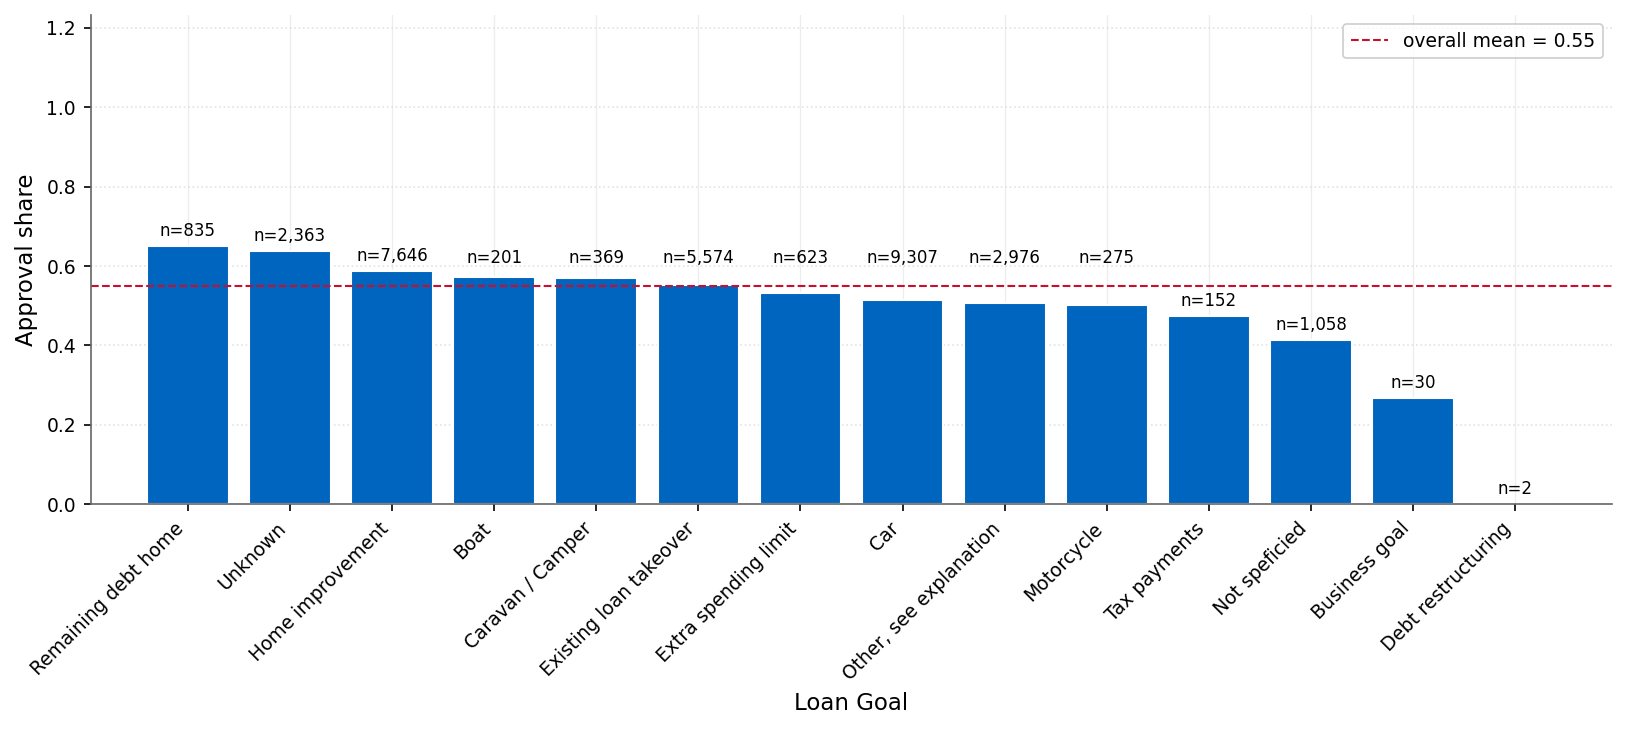

Saved: plots/A_01_approval_by_loangoal.png


In [39]:
# Define the event outcomes
APPROVED, DENIED, CANCELLED = "O_Accepted", "A_Denied", "A_Cancelled"
OUTCOME_EVENTS = [APPROVED, DENIED, CANCELLED]

# Per case, take the last recognized decision event ordered by timestamp
last_outcome = (
    df[df["concept:name"].isin(OUTCOME_EVENTS)]
    .sort_values("time:timestamp")
    .groupby("case:concept:name")["concept:name"].last()
    .reset_index().rename(columns={"concept:name": "outcome"})
)
last_outcome["approved"] = (last_outcome["outcome"] == APPROVED).astype(int)

# Aggregate approval share per LoanGoal, with canceled included in the denominator
merged = (df.drop_duplicates("case:concept:name")[["case:concept:name", "case:LoanGoal"]].merge(last_outcome, on="case:concept:name"))
approval_by_goal = (
    merged.groupby("case:LoanGoal")
    .agg(total=("approved", "count"), approved=("approved", "sum"))
    .assign(approval_rate=lambda d: d["approved"] / d["total"])
    .sort_values("approval_rate", ascending=False)
)
overall_mean = merged["approved"].mean()
print(approval_by_goal.to_string())
print(f"\nOverall approval share: {overall_mean:.3f}")

# Plot approval share by LoanGoal
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(approval_by_goal.index, approval_by_goal["approval_rate"], color="#0065BF", edgecolor="white")

# Annotate each bar with its sample size
for bar, n in zip(bars, approval_by_goal["total"]):
    _y = bar.get_height() + 0.015
    if overall_mean - 0.06 < bar.get_height() < overall_mean + 0.025: _y = overall_mean + 0.05
    ax.text(bar.get_x() + bar.get_width() / 2, _y, f"n={n:,}", ha="center", va="bottom", fontsize=8, color="black")

# Reference line for the overall mean
ax.axhline(overall_mean, color="#C8102E", linewidth=1, linestyle="--", label=f"overall mean = {overall_mean:.2f}")
_legend = ax.legend(loc="upper right")
_style_reference_legend(_legend)

# Finalize axis labels and layout
ax.set_xlabel("Loan Goal")
ax.set_ylabel("Approval share")
ax.set_ylim(0, 1.1)
plt.xticks(rotation=45, ha="right")
_style_graph_axes(ax)
_pad_top(ax)
fig.tight_layout(pad=1.2)

# Save the figure
plt.savefig("plots/A_01_approval_by_loangoal.png", dpi=300)
plt.show()
print("Saved: plots/A_01_approval_by_loangoal.png")


## 11: Offer Attribute Timing

Offer attributes only become not null after the first `O_Create Offer` event occurs in a case. This analysis shows at which event index offers typically arrive and how many cases receive an offer at all.

The distribution validates the necessity of the temporal masking strategy. If offers arrive late in the trace, a large share of prefixes will have `OfferPresent = 0`, making the masking approach non-trivial and worth documenting.

Cases with at least one offer event:  31,509
Cases with NO offer events:           0

First offer arrival : event index stats:
count    31509.000000
mean         8.824971
std          3.763081
min          5.000000
25%          5.000000
50%          8.000000
75%         11.000000
max        125.000000


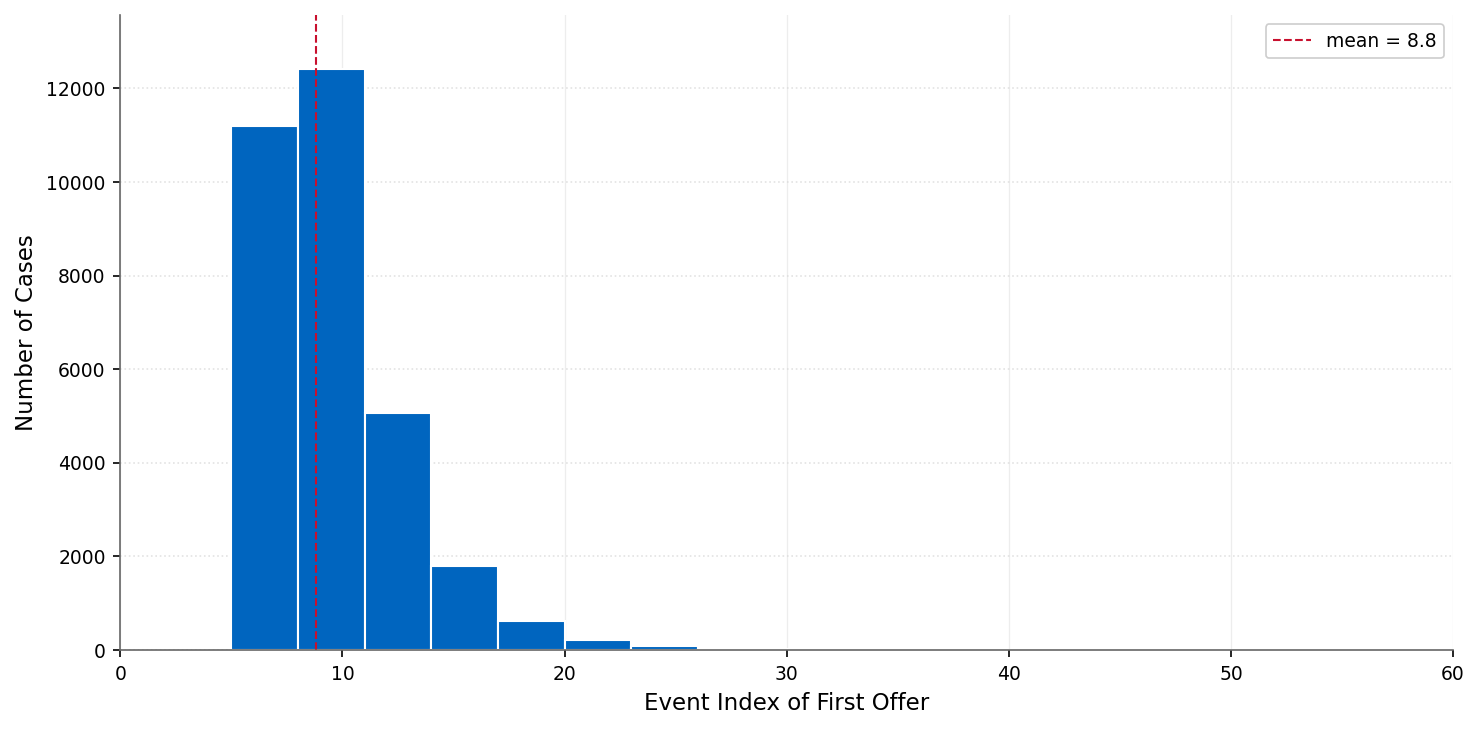

Saved: plots/A_01_offer_timing.png


In [40]:
# Define offer attributes
OFFER_ATTRS = ["CreditScore", "MonthlyCost", "OfferedAmount", "NumberOfTerms"]

# Sort events by case time and mark the first offer positions
df_sorted = df.sort_values(["case:concept:name", "time:timestamp"]).copy()
df_sorted["event_idx"] = df_sorted.groupby("case:concept:name").cumcount()
df_sorted["has_offer"] = df_sorted[OFFER_ATTRS].notna().any(axis=1)

# Find out when the first offer is usually made in trace
first_offer = (df_sorted[df_sorted["has_offer"]].groupby("case:concept:name")["event_idx"].min())

# Find cases without an offer made
n_with_offer = first_offer.notna().sum()
n_without_offer = n_cases - n_with_offer
print(f"Cases with at least one offer event:  {n_with_offer:,}")
print(f"Cases with NO offer events:           {n_without_offer:,}")
print(f"\nFirst offer arrival : event index stats:")
print(first_offer.describe().to_string())

# Plot Index of the first offer
fig, ax = plt.subplots(figsize=(10, 5))
first_offer.hist(bins=40, ax=ax, color="#0065BF", edgecolor="white")
ax.set_xlabel("Event Index of First Offer")
ax.set_ylabel("Number of Cases")
ax.set_xlim(0, 60)

# Mean reference line
_mean_val = first_offer.mean()
ax.axvline(_mean_val, color="#C8102E", linewidth=1, linestyle="--", label=f"mean = {_mean_val:,.1f}")
_legend = ax.legend(loc="upper right")
_style_reference_legend(_legend)

# Finalize axis labels and layout
_style_graph_axes(ax)
_pad_top(ax, fraction=0.04)
fig.tight_layout(pad=1.2)

# Save the figure
plt.savefig("plots/A_01_offer_timing.png", dpi=300)
plt.show()
print("Saved: plots/A_01_offer_timing.png")

## 12: Offers per Case

While Section 11 shows *when* the first offer arrives, this cell shows *how many* offers a case receives in total. Multiple offers per case are common. The bank may revise terms after an initial rejection or counter the offer by the applicant.

This matters for the forward-fill strategy: If a case has multiple offer events, the most recent offer's values overwrite the previous ones in the prefix. The distribution shows whether cases with multiple offers are a rare exception or a regular part of the process.

In [41]:
# Find out how many offers are made per case
offers_per_case = (df[df["concept:name"] == "O_Create Offer"].groupby("case:concept:name").size())

# Report the number of offers per case and distribution
print(f"Cases with >=1 offer: {offers_per_case.gt(0).sum():,} / {n_cases:,}")
print(f"\nOffers per case stats:")
print("-" * 72)
print(offers_per_case.describe().to_string())
print(f"\nDistribution:")
print("-" * 72)
print(offers_per_case.value_counts().sort_index().head(10).to_string())

Cases with >=1 offer: 31,509 / 31,509

Offers per case stats:
------------------------------------------------------------------------
count    31509.000000
mean         1.364531
std          0.714896
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         10.000000

Distribution:
------------------------------------------------------------------------
1     22950
2      6578
3      1348
4       443
5       126
6        30
7        16
8        13
9         3
10        2


## 13: Multiple Offer Case Diagnostics and `CreditScore = 0`

About 27% of cases contain more than one `O_Create Offer` event, where the bank revises the initial loan offer in response to a customer query or counter-proposal. This pattern with multiple offers is specific to BPIC 2017 and absent from BPIC 2012. It has to be understood before deciding whether to keep all offers and update offer features or decide for one (first, last).

The views below check whether cases with multiple offers concentrate in higher requested amounts or specific loan goals and compare the first two offers per case on `OfferedAmount`, `NumberOfTerms`, `CreditScore` and `MonthlyCost` to identify which dimensions are typically renegotiated.


#### Multi-Offer Case Profile

Frequency of cases with multiple offers and their concentration by requested amount and loan goal.

In [42]:
# Set attributes to be compared
case_col = "case:concept:name"
offer_attrs = ["CreditScore", "MonthlyCost", "OfferedAmount", "NumberOfTerms"]
case_attrs  = ["case:RequestedAmount", "case:LoanGoal", "case:ApplicationType"]

# Assign a chronological rank to each O_Create Offer event per case
offers = (df[df["concept:name"] == "O_Create Offer"].sort_values([case_col, "time:timestamp", "EventID"]).copy())
offers["offer_rank"] = offers.groupby(case_col).cumcount() + 1

# Build a case view with offer count and isolate multi-offer cases
offers_per_case = offers.groupby(case_col).size().rename("offers")
cases = (df.drop_duplicates(case_col)[[case_col] + case_attrs].merge(offers_per_case, left_on=case_col, right_index=True, how="left"))
cases["offers"] = cases["offers"].fillna(0).astype(int)
multi = cases[cases["offers"] > 1]

# Multi-offer frequency and offer count distribution
print("MULTI-OFFER CASES")
print("-" * 72)
print(f"Cases with multiple offers:  {len(multi):,} of {n_cases:,} ({len(multi) / n_cases:.1%})")
print(f"Offers per multi-offer case: mean={multi['offers'].mean():.2f}, median={multi['offers'].median():.0f}, max={multi['offers'].max():.0f}")

# RequestedAmount distribution: single-offer vs. multi-offer cases
amount_summary = (
    cases[cases["offers"] >= 1]
    .assign(group=lambda x_temp: x_temp["offers"].gt(1).map({False: "Single offer", True: "Multiple offers"}))
    .groupby("group")["case:RequestedAmount"]
    .agg(Cases="count", Mean="mean", Median="median",
         Q1=lambda s: s.quantile(.25), Q3=lambda s: s.quantile(.75))
)
print("\nREQUESTED AMOUNT BY OFFER GROUP")
print("-" * 72)
print(amount_summary.to_string(float_format = lambda x_temp: f"{x_temp:,.0f}"))

# Top 10 loan goals among multi-offer cases (absolute numbers)
loangoal_summary = (
    multi.groupby("case:LoanGoal")
    .agg(Cases = (case_col, "count"), MedianAmount = ("case:RequestedAmount", "median"), MeanOffers = ("offers", "mean"))
    .sort_values("Cases", ascending=False)
    .head(10)
)
print("\nTOP LOAN GOALS AMONG MULTI-OFFER CASES")
print("-" * 72)
print(loangoal_summary.to_string(formatters={
    "Cases":        lambda x_temp: f"{int(x_temp):,}",
    "MedianAmount": lambda x_temp: f"{x_temp:,.0f}",
    "MeanOffers":   lambda x_temp: f"{x_temp:.2f}",
}))

# Share of multi-offer cases by LoanGoal (relative numbers)
share_by_goal = (
    cases.assign(multi=cases["offers"] > 1)
         .groupby("case:LoanGoal")
         .agg(n_cases=(case_col, "count"), n_multi=("multi", "sum"))
         .assign(share_multi=lambda d: d["n_multi"] / d["n_cases"])
         .sort_values("share_multi", ascending=False)
)
print("\nSHARE OF MULTI-OFFER CASES BY LOAN GOAL:")
print("-" * 72)
print(share_by_goal.to_string(formatters={
    "n_cases":     lambda x_temp: f"{int(x_temp):,}",
    "n_multi":     lambda x_temp: f"{int(x_temp):,}",
    "share_multi": lambda x_temp: f"{x_temp:.1%}",
}))

MULTI-OFFER CASES
------------------------------------------------------------------------
Cases with multiple offers:  8,559 of 31,509 (27.2%)
Offers per multi-offer case: mean=2.34, median=2, max=10

REQUESTED AMOUNT BY OFFER GROUP
------------------------------------------------------------------------
                 Cases   Mean  Median    Q1     Q3
group                                             
Multiple offers   8559 17,382  15,000 7,000 25,000
Single offer     22950 15,805  12,000 5,500 20,000

TOP LOAN GOALS AMONG MULTI-OFFER CASES
------------------------------------------------------------------------
                       Cases MedianAmount MeanOffers
case:LoanGoal                                       
Car                    2,443       11,500       2.35
Home improvement       2,065       15,000       2.32
Existing loan takeover 1,658       18,235       2.38
Other, see explanation   730       15,000       2.31
Unknown                  566            0       2.33
Not s

#### Offer Attribute Changes Between First and Second Offer

For each offer attribute, the table reports how often the second offer deviates from the first and the median absolute delta among changed cases. `CreditScore` zeros are treated as missing before computing deltas.

In [43]:
 # Isolate the first and second offer per case and align them for delta computation
first = (
    offers[offers["offer_rank"] == 1][[case_col] + offer_attrs]
    .add_prefix("first_").rename(columns={"first_" + case_col: case_col})
)
second = (
    offers[offers["offer_rank"] == 2][[case_col] + offer_attrs]
    .add_prefix("second_").rename(columns={"second_" + case_col: case_col})
)
deltas = first.merge(second, on=case_col, how="inner")

# Count how often each attribute changes. CreditScore = 0 is treated as missing
rows = []
for attr in offer_attrs:
    f_vals = deltas[f"first_{attr}"]
    s_vals = deltas[f"second_{attr}"]
    if attr == "CreditScore":
        f_vals = f_vals.replace(0, pd.NA)
        s_vals = s_vals.replace(0, pd.NA)
    delta   = s_vals - f_vals
    changed = delta.notna() & delta.ne(0)
    rows.append({
        "Attribute":            attr,
        "Comparable":           delta.notna().sum(),
        "Changed":              changed.sum(),
        "ChangedShare":         changed.sum() / max(delta.notna().sum(), 1),
        "MedianDelta":          delta[changed].median(),
        "MedianAbsDelta":       delta[changed].abs().median(),
    })

change_summary = pd.DataFrame(rows)
change_summary["Comparable"]    = change_summary["Comparable"].map(lambda x_temp: f"{int(x_temp):,}")
change_summary["Changed"]       = change_summary["Changed"].map(lambda x_temp: f"{int(x_temp):,}")
change_summary["ChangedShare"]  = change_summary["ChangedShare"].map(lambda x_temp: f"{x_temp:.1%}")
for col in ["MedianDelta", "MedianAbsDelta"]:
    change_summary[col] = change_summary[col].map(lambda x_temp: "n/a" if pd.isna(x_temp) else f"{x_temp:,.2f}")

print("SECOND OFFER CHANGES RELATIVE TO FIRST OFFER")
print("-" * 72)
print(change_summary.to_string(index=False))

SECOND OFFER CHANGES RELATIVE TO FIRST OFFER
------------------------------------------------------------------------
    Attribute Comparable Changed ChangedShare MedianDelta MedianAbsDelta
  CreditScore          2       0         0.0%         n/a            n/a
  MonthlyCost      8,559   6,240        72.9%       -0.85          13.71
OfferedAmount      8,559   2,998        35.0%      600.00       4,000.00
NumberOfTerms      8,559   3,682        43.0%        1.00          10.00


#### CreditScore Availability Transitions

`CreditScore` is treated as missing when zero. This cell tracks how often the score transitions from missing to available or vice versa between the first and second offer and whether those transitions coincide with changes in other offer terms.

In [44]:
# CreditScore availability transitions between first and second offer
score_0_to_value = deltas["first_CreditScore"].eq(0)  & deltas["second_CreditScore"].ne(0)
score_value_to_0 = deltas["first_CreditScore"].ne(0)  & deltas["second_CreditScore"].eq(0)

# Flag 0 -> nonzero transitions where other offer terms also changed
other_changed = pd.DataFrame({
    attr: (deltas[f"second_{attr}"] - deltas[f"first_{attr}"]).fillna(0).ne(0)
    for attr in ["MonthlyCost", "OfferedAmount", "NumberOfTerms"]
})

print("CREDITSCORE AVAILABILITY TRANSITIONS (FIRST TO SECOND OFFER)")
print("-" * 72)
print(f"0 -> nonzero:                            {int(score_0_to_value.sum()):,}")
print(f"nonzero -> 0:                            {int(score_value_to_0.sum()):,}")
print(f"0 -> nonzero with other term changes:    {int((score_0_to_value &  other_changed.any(axis=1)).sum()):,}")
print(f"0 -> nonzero without other term changes: {int((score_0_to_value & ~other_changed.any(axis=1)).sum()):,}")

CREDITSCORE AVAILABILITY TRANSITIONS (FIRST TO SECOND OFFER)
------------------------------------------------------------------------
0 -> nonzero:                            2,891
nonzero -> 0:                            905
0 -> nonzero with other term changes:    2,151
0 -> nonzero without other term changes: 740


## 14: Temporal Distribution of Case Starts

Shows how many new loan applications were submitted each month across the observation window. An uneven distribution means the temporal train/val/test split (60/20/20 by case start time) will not cover all months equally. The test set will always be the most recent period.

This is intentional: Temporal splitting prevents leakage and reflects real deployment conditions. The plot confirms there are no large gaps or data collection anomalies in the log.

time:timestamp
2016-01    2194
2016-02    2412
2016-03    2454
2016-04    2177
2016-05    2068
2016-06    3001
2016-07    3039
2016-08    3085
2016-09    3042
2016-10    2995
2016-11    2676
2016-12    2366
Freq: M


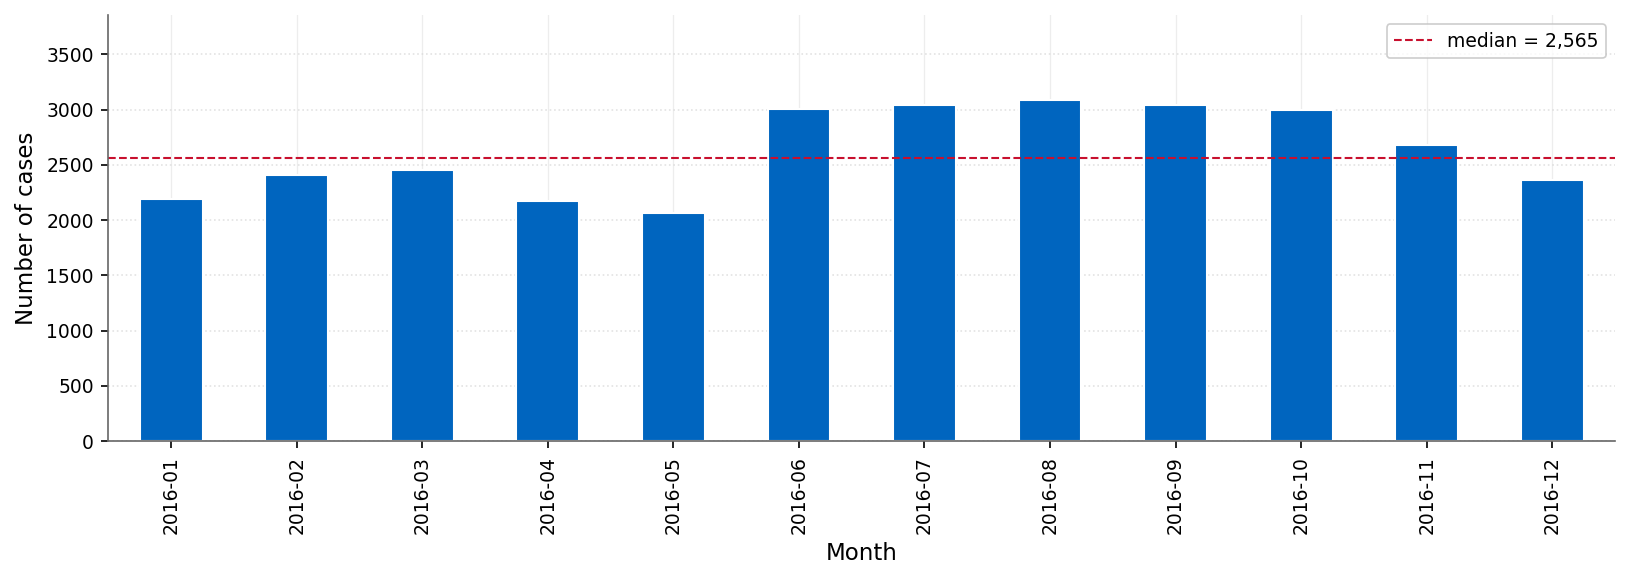

In [45]:
# Find the temporal distribution of case starts
case_starts = df.groupby("case:concept:name")["time:timestamp"].min()
monthly_starts = (case_starts.dt.tz_localize(None).dt.to_period("M").value_counts().sort_index())
print(monthly_starts.to_string())

# Plot the temporal distribution by index
fig, ax = plt.subplots(figsize=(11, 4))
monthly_starts.plot(kind="bar", ax=ax, color="#0065BF", edgecolor="white", legend=False)
_median_val = float(monthly_starts.median())
_median_line = ax.axhline(_median_val, color="#C8102E", linewidth=1, linestyle="--", label=f"median = {_median_val:,.0f}")
_legend = ax.legend(handles=[_median_line], loc="upper right")
_style_reference_legend(_legend)
ax.set_ylim(0, monthly_starts.max() * 1.25)
ax.set(xlabel="Month", ylabel="Number of cases")

# Finalize axis labels, layout and save
_style_graph_axes(ax)
fig.tight_layout(pad=1.2)
plt.savefig("plots/A_01_case_starts_by_month.png", dpi=300)
plt.show()

## 15: Resource Attribute and Cardinality

Brief inspection of `org:resource` to see what identifiers appear, how many distinct resources the log contains and how the event volume is distributed among them. This informs whether `org:resource` is a viable categorical input for the prefix encoder later on.

In [46]:
# High-level inspection of org:resource in the BPIC 2017 log
resource_col = "org:resource"

# Sample values and presence of nulls
n_total_events = len(df)
n_missing = df[resource_col].isna().sum()
n_unique = df[resource_col].nunique(dropna=True)

print(f"Total events:              {n_total_events:,}")
print(f"Distinct org:resource:     {n_unique:,}")
print(f"Events without resource:   {n_missing:,} ({n_missing / n_total_events:.2%})")

# Example identifiers
print("\nSAMPLE OF RESOURCE IDENTIFIERS:")
print("-" * 72)
print(sorted(df[resource_col].dropna().unique())[:10])

# Events per resource: how concentrated is the workload?
events_per_resource = (df[resource_col].value_counts(dropna=True).rename_axis("org:resource").reset_index(name="n_events"))

print("\nTOP 10 RESOURCES BY EVENT VOLUME:")
print("-" * 72)
print(events_per_resource.head(10).to_string(index=False))
print("\nBOTTOM 5 RESOURCES BY EVENT VOLUME:")
print("-" * 72)
print(events_per_resource.tail(5).to_string(index=False))

# Summary statistics across resources
print("\nEVENTS PER RESOURCE, SUMMARY STATISTICS:")
print("-" * 72)
print(events_per_resource["n_events"].describe().round(1).to_string())

Total events:              1,202,267
Distinct org:resource:     149
Events without resource:   0 (0.00%)

SAMPLE OF RESOURCE IDENTIFIERS:
------------------------------------------------------------------------
['User_1', 'User_10', 'User_100', 'User_101', 'User_102', 'User_103', 'User_104', 'User_105', 'User_106', 'User_107']

TOP 10 RESOURCES BY EVENT VOLUME:
------------------------------------------------------------------------
org:resource  n_events
      User_1    148404
      User_3     26342
      User_5     22900
     User_87     22498
     User_30     21272
     User_49     21134
    User_123     20909
     User_29     20860
    User_100     20651
      User_2     19134

BOTTOM 5 RESOURCES BY EVENT VOLUME:
------------------------------------------------------------------------
org:resource  n_events
    User_146        23
    User_145        10
    User_148         4
    User_147         2
    User_149         2

EVENTS PER RESOURCE, SUMMARY STATISTICS:
--------------------

## 16: MD5 Hash of the Dataset File

Reproducibility requires that analysis, plots and results reported can be retraced to the exact same input file. Even a partial re-download or a silent encoding change could change the behavior of the system and propagate to the final results.

To guard against this, the MD5 hash of the uncompressed `BPI Challenge 2017.xes` file is recorded below. The hash, the file size in bytes and the source DOI are also logged in the repository README.md.

In [47]:
import hashlib
from pathlib import Path

# MD5 hash of a file, computed in 1 MB chunks
def file_md5(path, chunk_size=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""): h.update(chunk)
    return h.hexdigest()

xes_path = Path("BPI Challenge 2017/BPI Challenge 2017.xes")
print(f"File:    {xes_path.name}")
print(f"Size:    {xes_path.stat().st_size:,} bytes")
print(f"MD5:     {file_md5(xes_path)}")

File:    BPI Challenge 2017.xes
Size:    578,941,403 bytes
MD5:     3b8eefc5a5981c48451af0513e1669d3


In [48]:
# ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
#                          TUM · zeb  |  Cornelius Weiss · M.Sc. Wirtschaftsinformatik · 2026
# ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────